# Latent Class Analysis

Run linear regression for each patient and perform a cluster analysis to see how many classes generates the best results

Perform trajectory based clustering 

In [1]:
# Ensure that we are using the correct host
import socket
try:
    assert "gpu" in socket.gethostname()
    print(f"Running on {socket.gethostname()}. All is good!")
except:
    raise RuntimeError(f"Be sure to run on GPU! You are currently running on {socket.gethostname()}")

Running on gpu14.storrs.hpc.uconn.edu. All is good!


In [2]:
import subprocess
subprocess.run(["pip", "install", "scikit-learn", "matplotlib", "pandas", "numpy"], check=True)


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['pip', 'install', 'scikit-learn', 'matplotlib', 'pandas', 'numpy'], returncode=0)

In [3]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

Load the data 

In [4]:
file_path = r"/shared/healthinfolab/datasets/ABCD/ScreenTime/dataset.tsv/dataset.tsv"
df = pd.read_csv(file_path, sep="\t")

# Select relevant columns: participant_id, session_id (specific wave), and nt_y_earsapp__mins_mean
df = df[[
    "participant_id",
    "session_id",
    "nt_y_earsapp__mins_mean"
]]

# Convert to numeric
df["nt_y_earsapp__mins_mean"] = pd.to_numeric(
    df["nt_y_earsapp__mins_mean"],
    errors="coerce"
)

# Remove negative values
df = df[df["nt_y_earsapp__mins_mean"] >= 0]


/tmp/ipykernel_3423377/2507151228.py:2: DtypeWarning: Columns (0: nt_y_earsplt__start_dtt, 1: nt_y_earsplt__end_dtt) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep="\t")


Keep only the Target Waves

In [5]:
target_waves = ["ses-00A", "ses-01A", "ses-02A", "ses-03A", "ses-04A", "ses-05A"]

# Map session_id to a numeric time index (0–5) for regression
wave_to_time = {wave: i for i, wave in enumerate(target_waves)}

df = df[df["session_id"].isin(target_waves)].copy()
df["time"] = df["session_id"].map(wave_to_time)

print(f"Rows after filtering: {len(df)}")
print(f"Unique participants: {df['participant_id'].nunique()}")


Rows after filtering: 1871
Unique participants: 1391


# Fit Per-participant linear regression 

each participant gets their own OLS fit on whatever waves they have data for; requires a minimum of 2 observations to estimate a line 

In [6]:
MIN_OBSERVATIONS = 2  # Minimum waves needed to fit a regression

records = []

for pid, group in df.groupby("participant_id"):
    group = group.dropna(subset=["nt_y_earsapp__mins_mean"])
    
    if len(group) < MIN_OBSERVATIONS:
        continue
    
    X = group["time"].values.reshape(-1, 1)
    y = group["nt_y_earsapp__mins_mean"].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    records.append({
        "participant_id": pid,
        "intercept": model.intercept_,       # Estimated screen time at wave 0
        "slope": model.coef_[0],             # Change in screen time per wave
        "n_obs": len(group)
    })

reg_df = pd.DataFrame(records)
print(f"Participants with regressions fit: {len(reg_df)}")
print(reg_df[["intercept", "slope", "n_obs"]].describe())

Participants with regressions fit: 480


         intercept       slope  n_obs
count   480.000000  480.000000  480.0
mean    168.490750   34.058229    2.0
std     696.963621  150.536320    0.0
min   -2588.540000 -581.750000    2.0
25%    -216.790000  -41.077500    2.0
50%     136.910000   35.050000    2.0
75%     544.437500  110.362500    2.0
max    3220.470000  698.650000    2.0


Standardize the slope and intercept

In [7]:
feature_cols = ["intercept", "slope"]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(reg_df[feature_cols])
features_scaled_df = pd.DataFrame(features_scaled, columns=feature_cols)

# Model Selection
using BIC and AIC across 1-5 classes

   Classes          BIC          AIC
0        1  1298.679740  1277.810809
1        2  1305.744609  1259.832962
2        3  1282.464114  1211.509750
3        4  1298.765664  1202.768584
4        5  1313.499363  1192.459566


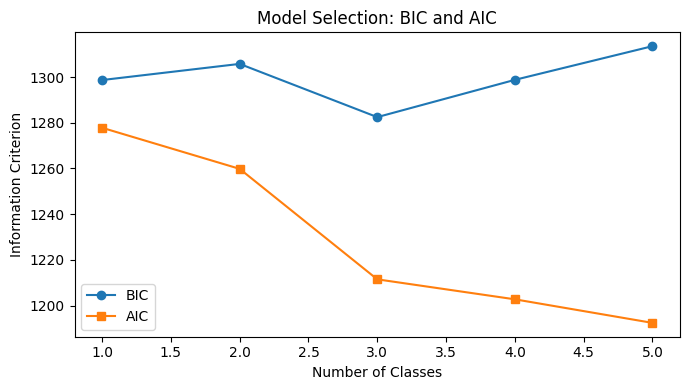

In [8]:
results = []

for k in range(1, 6):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=10  # Multiple inits for stability
    )
    gmm.fit(features_scaled_df)
    
    results.append({
        "Classes": k,
        "BIC": gmm.bic(features_scaled_df),
        "AIC": gmm.aic(features_scaled_df)
    })

results_df = pd.DataFrame(results)
print(results_df)

# Plot BIC and AIC
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results_df["Classes"], results_df["BIC"], marker="o", label="BIC")
ax.plot(results_df["Classes"], results_df["AIC"], marker="s", label="AIC")
ax.set_xlabel("Number of Classes")
ax.set_ylabel("Information Criterion")
ax.set_title("Model Selection: BIC and AIC")
ax.legend()
plt.tight_layout()
plt.savefig("model_selection.png", dpi=150)
plt.show()

Fit the final model - choosing 3 classes basked on the elbow in the BIC?AIC

In [9]:
N_CLASSES = 3  # <-- update based on BIC/AIC plot

best_model = GaussianMixture(
    n_components=N_CLASSES,
    covariance_type="full",
    random_state=42,
    n_init=10
)
best_model.fit(features_scaled_df)

reg_df["LPA_class"] = best_model.predict(features_scaled_df)

print("Class distribution:")
print(reg_df["LPA_class"].value_counts().sort_index())

Class distribution:
LPA_class
0    322
1     75
2     83
Name: count, dtype: int64


Visualize the trajectory classes - plot the mean predicted trjectory (slope x time + intercpet) for each class in the orginal (unstandardized) scale

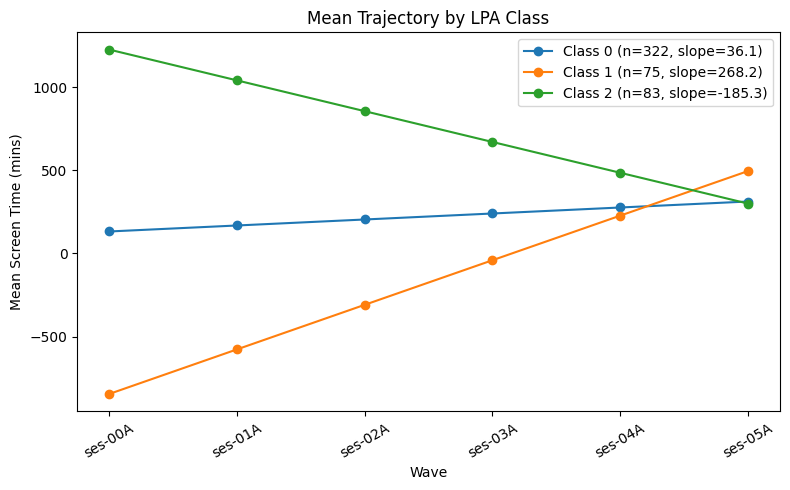

In [10]:
time_points = np.arange(len(target_waves))  # 0–5

fig, ax = plt.subplots(figsize=(8, 5))

for cls in sorted(reg_df["LPA_class"].unique()):
    subset = reg_df[reg_df["LPA_class"] == cls]
    mean_intercept = subset["intercept"].mean()
    mean_slope = subset["slope"].mean()
    n = len(subset)
    
    trajectory = mean_intercept + mean_slope * time_points
    ax.plot(
        time_points, trajectory,
        marker="o",
        label=f"Class {cls} (n={n}, slope={mean_slope:.1f})"
    )

ax.set_xticks(time_points)
ax.set_xticklabels(target_waves, rotation=30)
ax.set_xlabel("Wave")
ax.set_ylabel("Mean Screen Time (mins)")
ax.set_title("Mean Trajectory by LPA Class")
ax.legend()
plt.tight_layout()
plt.savefig("trajectory_classes.png", dpi=150)
plt.show()

Create individual trajectories by class - each participant's regression line is plotted with high transparency (bold line = class mean)

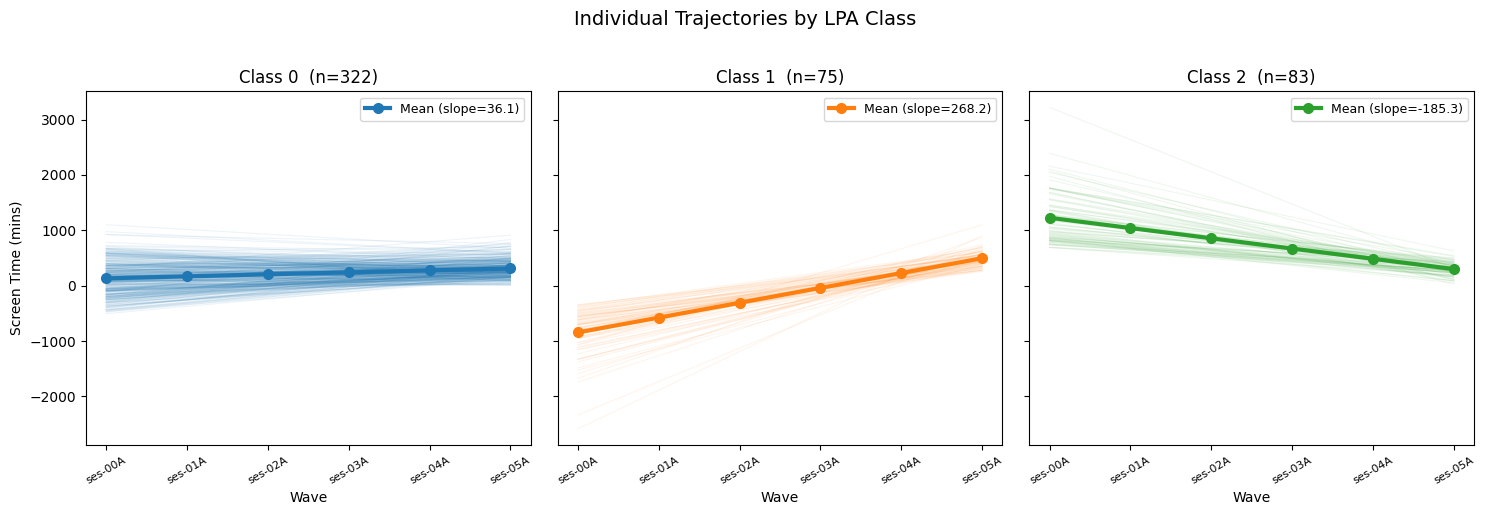

In [11]:
# One subplot per class
classes = sorted(reg_df["LPA_class"].unique())
n_classes = len(classes)
colors = plt.cm.tab10.colors  # distinct color per class

fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 5), sharey=True)

# Handle single-class edge case
if n_classes == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    subset = reg_df[reg_df["LPA_class"] == cls]
    color = colors[cls % len(colors)]

    # --- Individual lines ---
    for _, row in subset.iterrows():
        y_ind = row["intercept"] + row["slope"] * time_points
        ax.plot(
            time_points, y_ind,
            color=color,
            alpha=0.08,       # high transparency
            linewidth=0.8,
            zorder=1
        )

    # --- Class mean line ---
    mean_traj = subset["intercept"].mean() + subset["slope"].mean() * time_points
    ax.plot(
        time_points, mean_traj,
        color=color,
        linewidth=3,
        marker="o",
        markersize=7,
        zorder=2,
        label=f"Mean (slope={subset['slope'].mean():.1f})"
    )


    ax.set_title(f"Class {cls}  (n={len(subset)})", fontsize=12)
    ax.set_xticks(time_points)
    ax.set_xticklabels(target_waves, rotation=30, fontsize=8)
    ax.set_xlabel("Wave")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Screen Time (mins)")
fig.suptitle("Individual Trajectories by LPA Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("individual_trajectories_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

Save the output 

In [12]:
output_df = reg_df[["participant_id", "intercept", "slope", "n_obs", "LPA_class"]]
output_df.to_csv("longitudinal_ears_lpa.csv", index=False)

print("Saved to longitudinal_ears_lpa.csv")
print(output_df.head())

Saved to longitudinal_ears_lpa.csv
  participant_id  intercept   slope  n_obs  LPA_class
0   sub-005V6D2C      52.29   51.61      2          0
1   sub-00HEV6HB     -68.29   44.77      2          0
2   sub-06DE9Y0L      26.08   81.49      2          0
3   sub-06DJHEV0   -1232.21  353.31      2          1
4   sub-0889M0JE     669.23  -47.91      2          0
